# Extração e EDA — Petróleo Brent (IPEA Data)

Tech Challenge Fase 4 (Prova Substitutiva) — FIAP POSTECH.

Série oficial: `EIA366_PBRENT366` (serid `1650971490`), preço Brent FOB em US$/barril.

In [1]:
%matplotlib inline
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.data_loader import load_or_refresh, series_summary, IPEA_SERCODIGO, IPEA_SERID

raw = load_or_refresh(refresh=False)
summary = series_summary(raw)
display(pd.Series(summary, name='serie'))
raw.tail()

n_obs                    10049
start               1987-05-20
end                 2026-08-25
last_price               88.24
min_price                  9.1
max_price               143.95
source        EIA366_PBRENT366
serid               1650971490
Name: serie, dtype: object

,date,price,sercodigo
10044,2026-08-19,92.37,EIA366_PBRENT366
10045,2026-08-20,94.00,EIA366_PBRENT366
10046,2026-08-21,96.92,EIA366_PBRENT366
10047,2026-08-24,92.71,EIA366_PBRENT366
10048,2026-08-25,88.24,EIA366_PBRENT366


## Trajetória histórica (1987 aos dias atuais)

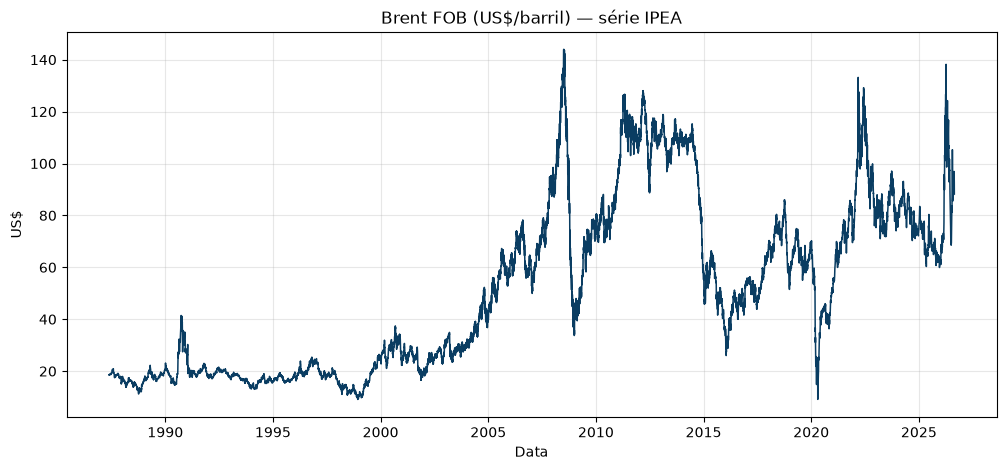

In [2]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(raw['date'], raw['price'], color='#0A3D62', linewidth=1.1)
ax.set_title('Brent FOB (US$/barril) — série IPEA')
ax.set_xlabel('Data')
ax.set_ylabel('US$')
ax.grid(True, alpha=0.3)
plt.show()

## Cinco choques geopolíticos e econômicos

- **1990** — Guerra do Golfo.
- **2008** — Crise dos subprimes / pico acima de US$ 140.
- **2014** — Guerra de preços da OPEP.
- **2020** — COVID-19 e choque de demanda.
- **2022** — Conflito Rússia–Ucrânia.

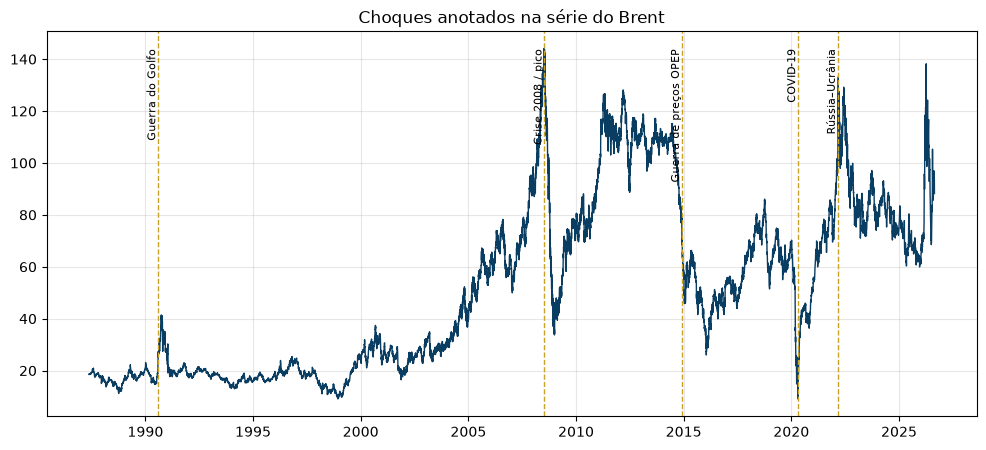

In [3]:
events = [
    ('1990-08-02', 'Guerra do Golfo'),
    ('2008-07-11', 'Crise 2008 / pico'),
    ('2014-11-27', 'Guerra de preços OPEP'),
    ('2020-04-21', 'COVID-19'),
    ('2022-02-24', 'Rússia–Ucrânia'),
]
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(raw['date'], raw['price'], color='#0A3D62', linewidth=1.0)
ymax = raw['price'].max()
for date, title in events:
    ts = pd.Timestamp(date)
    ax.axvline(ts, color='#C9A227', linestyle='--', linewidth=1)
    ax.text(ts, ymax, title, rotation=90, va='top', ha='right', fontsize=8)
ax.set_title('Choques anotados na série do Brent')
ax.grid(True, alpha=0.3)
plt.show()

## Decomposição temporal (tendência, sazonalidade anual e resíduo)

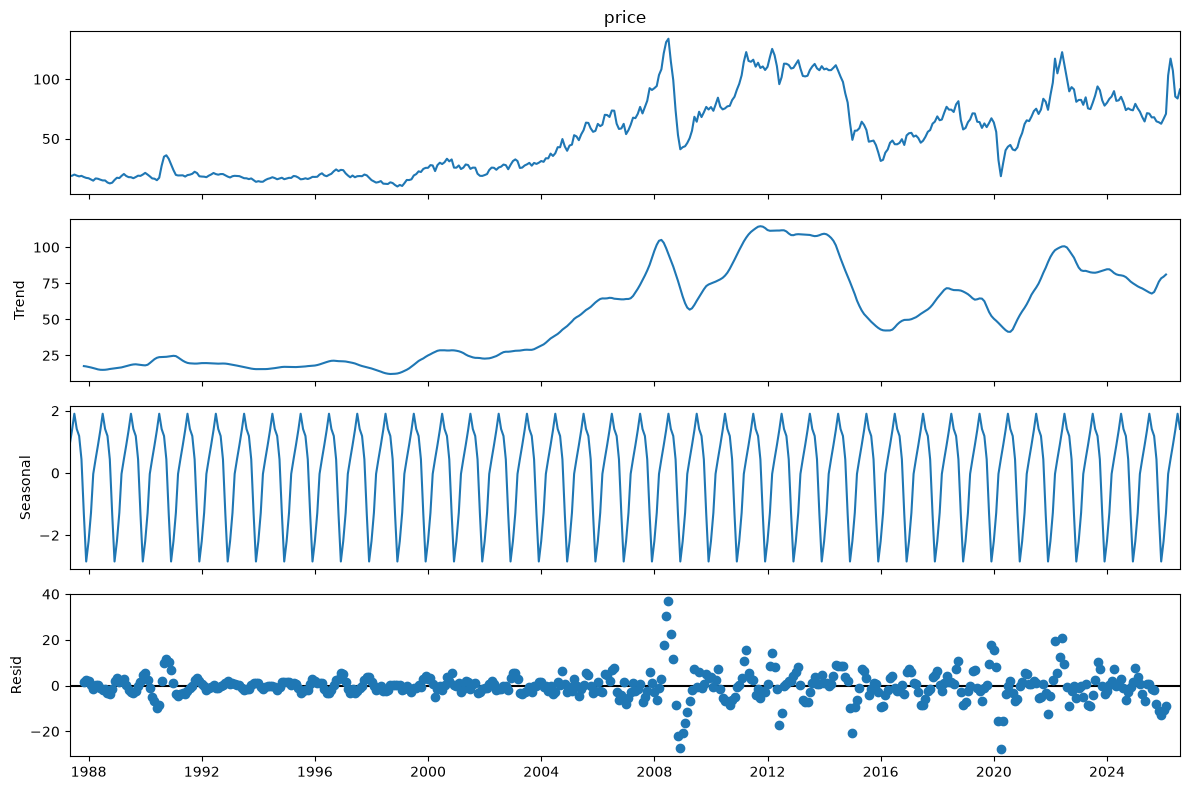

In [4]:
monthly = raw.set_index('date')['price'].resample('MS').mean().dropna()
decomp = seasonal_decompose(monthly, model='additive', period=12)
fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

## Teste de estacionariedade (Augmented Dickey-Fuller)

In [5]:
def adf_report(series, label):
    series = series.dropna()
    stat, pvalue, lags, nobs, crit, _ = adfuller(series, autolag='AIC')
    return {
        'serie': label,
        'adf': stat,
        'p_valor': pvalue,
        'lags': lags,
        'n': nobs,
        'critico_5%': crit['5%'],
        'estacionaria_5%': pvalue < 0.05,
    }

level = raw.set_index('date')['price']
reports = [
    adf_report(level, 'preco_nivel'),
    adf_report(level.diff(), 'primeira_diferenca'),
]
display(pd.DataFrame(reports))

/tmp/ipykernel_5895/2366663996.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat, pvalue, lags, nobs, crit, _ = adfuller(series, autolag='AIC')


/tmp/ipykernel_5895/2366663996.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat, pvalue, lags, nobs, crit, _ = adfuller(series, autolag='AIC')


,serie,adf,p_valor,lags,n,critico_5%,estacionaria_5%
0,preco_nivel,-2.312744,1.678906e-01,38,10010,-2.861829,False
1,primeira_diferenca,-14.913254,1.447833e-27,37,10010,-2.861829,True


A série em nível costuma ser não estacionária (passeio próximo a um processo integrado). A primeira diferença tende a rejeitar a hipótese nula do ADF — padrão típico de preço de commodity.